In [30]:
import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import dataloader
from torch.utils.data import random_split, DataLoader
import threading
import copy

from Classe_agent import Agent



# PyTorch CNN

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

We will do the following steps in order:

1.Load and normalize the CIFAR10 training and test datasets using torchvision

2.Define a Convolutional Neural Network

3.Define a loss function

4.Train the network on the training data

5.Test the network on the test data

In [31]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 4
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
torch.version
torch.version.cuda
torch.cuda.is_available()

True

In [33]:
transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [34]:
# Taille du dataset
train_size = len(trainset)

# Split en 2 parties
split1 = train_size // 2
split2 = train_size - split1

dataset1, dataset2 = random_split(trainset, [split1, split2])

# DataLoaders
trainloader1 = DataLoader(dataset1, batch_size=BATCH_SIZE, shuffle=True)
trainloader2 = DataLoader(dataset2, batch_size=BATCH_SIZE, shuffle=True)

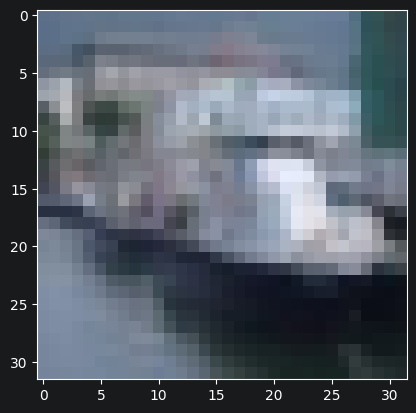

In [35]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
img = images[0] * 0.5 + 0.5
plt.imshow(img.permute(1, 2, 0))
#imshow(torchvision.utils.make_grid(images))

# Define a Convolutional Neural Network

In [36]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1) # flatten all dimensions except batch
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x


net1 = Net().to(DEVICE)
net2 = Net().to(DEVICE)


# Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

In [37]:
criterion = nn.CrossEntropyLoss()

optimizer1 = optim.SGD(net1.parameters(), lr=LEARING_RATE, momentum=MOMENTUM)
optimizer2 = optim.SGD(net2.parameters(), lr=LEARING_RATE, momentum=MOMENTUM)

In [38]:
list_graphe = [x * NUM_EPOCHES for x in range(NUM_EPOCHES)]

In [39]:
def plot_metrics(train_losses,train_accuracies, val_losses, val_accuracies, model_name):

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # LOSS
    axes[0].plot(epochs, train_losses, label="Train Loss")
    axes[0].plot(epochs, val_losses, label="Validation Loss")

    axes[0].set_title(f"{model_name} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # ACCURACY
    axes[1].plot(epochs, train_accuracies, label="Train Accuracy")
    axes[1].plot(epochs, val_accuracies, label="Validation Accuracy")


    axes[1].set_title(f"{model_name} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.show()

# 4. Train the network

In [40]:
def synchronize_models_average(model1, model2):

    state_dict1 = model1.state_dict()
    state_dict2 = model2.state_dict()

    # Nouveau dictionnaire moyen
    new_state_dict = {}

    for key in state_dict1:

        new_state_dict[key] = (
            state_dict1[key] + state_dict2[key]
        ) / 2

    # Charger les nouveaux poids
    model1.load_state_dict(new_state_dict)
    model2.load_state_dict(new_state_dict)

In [41]:
def synchronize_models(model1, model2):

    state_dict1 = copy.deepcopy(model1.state_dict())
    state_dict2 = copy.deepcopy(model2.state_dict())

    # Charger les nouveaux poids
    model1.load_state_dict(state_dict2)
    model2.load_state_dict(state_dict1)

In [42]:
def validate(net,testloader):
    net.eval()

    running_loss = 0
    correct = 0
    total = 0
    accuracy = 0

    with torch.no_grad():

        for inputs, labels in testloader:

            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = net(inputs)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(testloader)
    accuracy += 100*correct / total

    return avg_loss, accuracy


In [43]:
def train_one_epoch(net, trainloader, optimizer):

    net.train()

    running_loss = 0.0

    for inputs, labels in trainloader:

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = net(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    # Loss train
    avg_train_loss = running_loss / len(trainloader)

    return avg_train_loss

In [ ]:
criterion = nn.CrossEntropyLoss()

train_losses1 = []
train_accuracies1 = []
val_losses1 = []
val_acc1 = []

train_losses2 = []
train_accuracies2 = []
val_losses2 = []
val_acc2 = []


for epoch in range(NUM_EPOCHES):

    #agent1.val_one_epoch(agent1, trainloader1)
    #agent2.train_one_epoch(agent2, trainloader2)

    # THREADS
    thread1 = threading.Thread(
        target=train_one_epoch,
        args=(net1, trainloader1, optimizer1)
    )

    thread2 = threading.Thread(
        target=train_one_epoch,
        args=(net2, trainloader2, optimizer2)
    )



    # Start des deux modèles
    thread1.start()
    thread2.start()

    # Attendre la fin
    thread1.join()
    thread2.join()

    # Synchronisation des poids
    synchronize_models_average(net1, net2)

    # VALIDATION
    train_loss1 = train_one_epoch(net1, trainloader1, optimizer1)
    val_loss1, acc1 = validate(net1, testloader)

    train_loss2 = train_one_epoch(net2, trainloader2, optimizer2)
    val_loss2, acc2 = validate(net2, testloader)

    # SAVE METRICS
    train_losses1.append(train_loss1)
    val_losses1.append(val_loss1)
    val_acc1.append(acc1)

    train_losses2.append(train_loss2)
    val_losses2.append(val_loss2)
    val_acc2.append(acc2)

    # PRINT
    print(
        f"Epoch {epoch+1} | "
        f"Model1 Acc: {acc1:.2f}% | "
        f"Model2 Acc: {acc2:.2f}%"
    )

print("Les deux modèles ont fini l'entraînement")

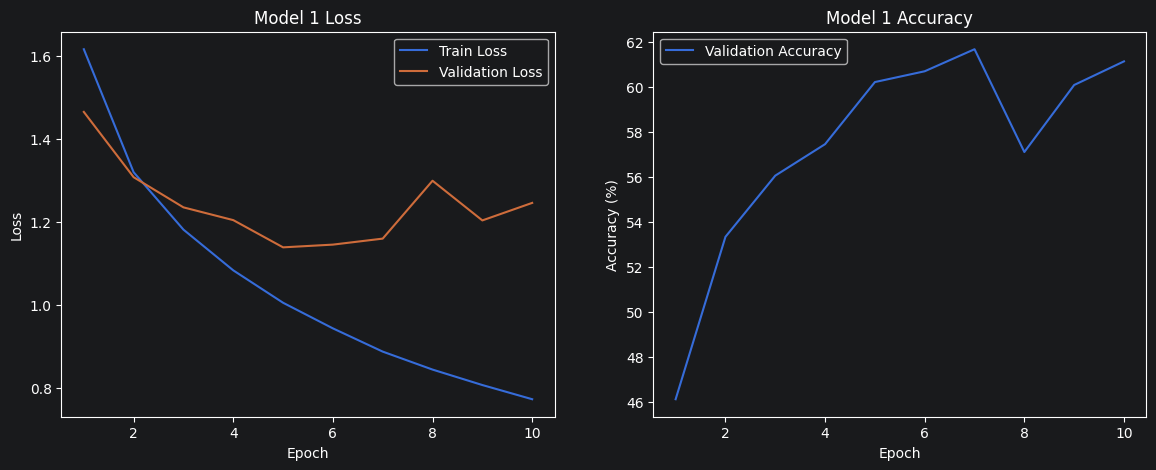

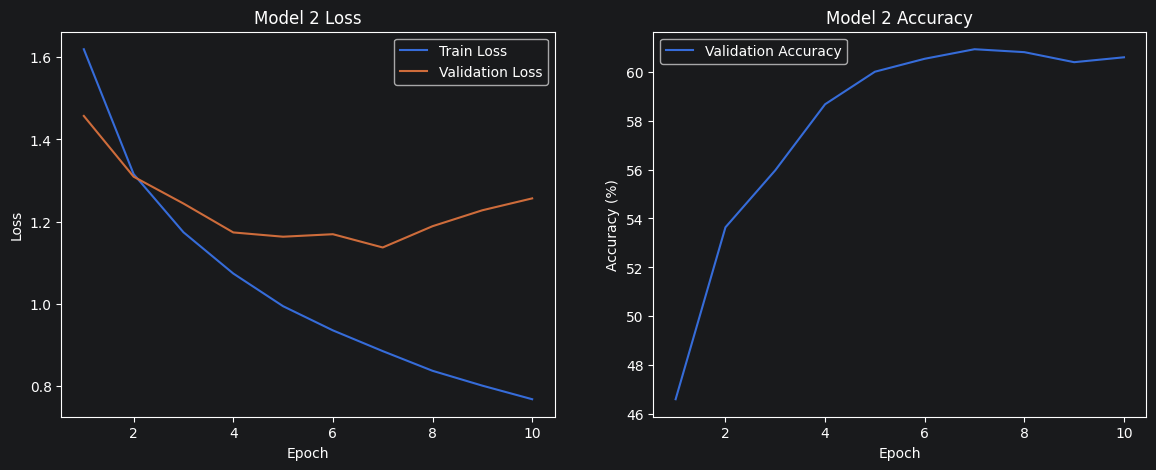

In [26]:
plot_metrics(train_losses1,train_accuracies1, val_losses1, val_acc1, "Model 1")
plot_metrics(train_losses2,train_accuracies2, val_losses2, val_acc2, "Model 2")

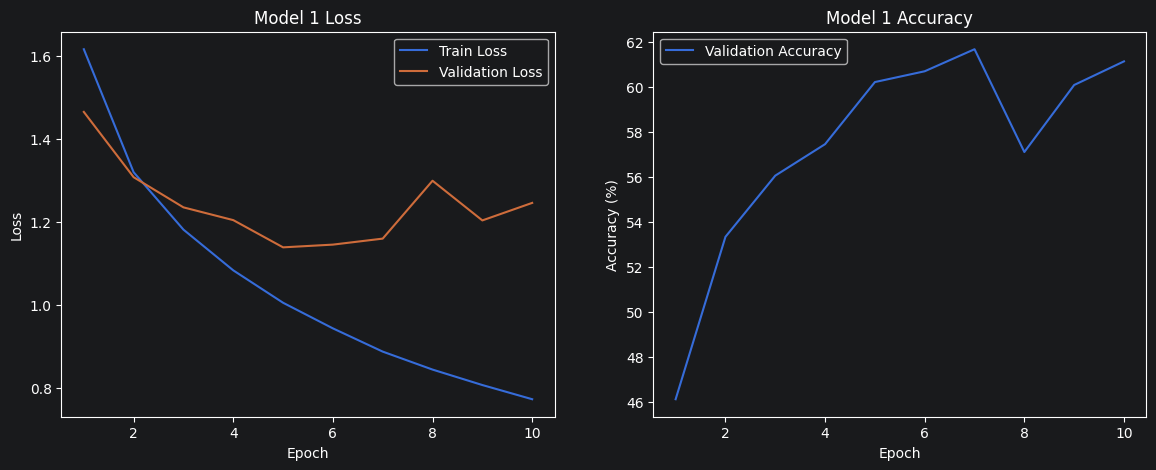

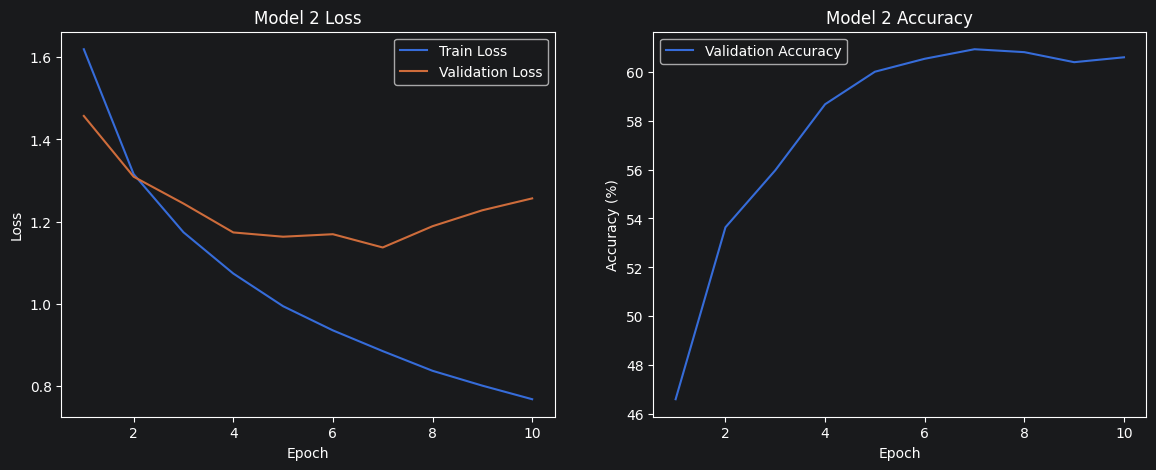

In [17]:
plot_metrics(train_losses1, val_losses1, val_acc1, "Model 1")
plot_metrics(train_losses2, val_losses2, val_acc2, "Model 2")

# 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

dataiter = iter(testloader)

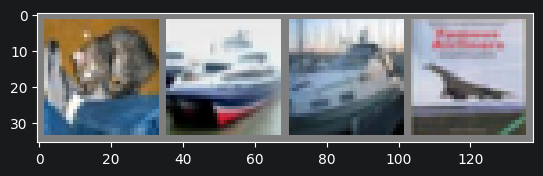

GroundTruth:  cat   ship  ship  plane


In [18]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [19]:
# Après avoir entraîné ton modèle

model.eval()
with torch.no_grad():
    # Prends une image de test
    images, labels = next(iter(testloader))

    # Prédiction
    outputs = model(images[0].unsqueeze(0))

    # Afficher les scores pour les 10 classes
    for i, (classe, score) in enumerate(zip(classes, outputs[0])):
        barre = '█' * int(score * 2)  # Barre visuelle
        print(f"Neurone #{i} ({classe:5s}) : {barre} {score:.2f}")

    # La classe prédite est celle avec le score le plus élevé
    predicted = torch.argmax(outputs, dim=1)
    print(f"\n✅ Prédiction : {classes[predicted]}")
    print(f"   Vérité     : {classes[labels[0]]}")

NameError: name 'model' is not defined